# Importing Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Dataset

In [2]:
df_fruit = pd.read_excel('fruit.xlsx')
df_fruit

,diameter,weight,red,green,blue,name
0,2.96,86.76,172,85,2,orange
1,3.91,88.05,166,78,3,orange
2,4.42,95.17,156,81,2,orange
3,4.47,95.60,163,81,4,orange
4,4.48,95.76,161,72,9,orange
...,...,...,...,...,...,...
9995,15.35,253.89,149,77,20,grapefruit
9996,15.41,254.67,148,68,7,grapefruit
9997,15.59,256.50,168,82,20,grapefruit
9998,15.92,260.14,142,72,11,grapefruit


# Encoder

In [3]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df_fruit['name_encoded'] = label_encoder.fit_transform(df_fruit['name'])

In [4]:
df_fruit

,diameter,weight,red,green,blue,name,name_encoded
0,2.96,86.76,172,85,2,orange,1
1,3.91,88.05,166,78,3,orange,1
2,4.42,95.17,156,81,2,orange,1
3,4.47,95.60,163,81,4,orange,1
4,4.48,95.76,161,72,9,orange,1
...,...,...,...,...,...,...,...
9995,15.35,253.89,149,77,20,grapefruit,0
9996,15.41,254.67,148,68,7,grapefruit,0
9997,15.59,256.50,168,82,20,grapefruit,0
9998,15.92,260.14,142,72,11,grapefruit,0


# Split Dependent & Independent

In [5]:
X = df_fruit[['diameter', 'weight', 'red','green','blue']].values
y = df_fruit['name_encoded'].values

# Split the Dataset

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [7]:
df_fruit['name'].value_counts()

name
orange        5000
grapefruit    5000
Name: count, dtype: int64

# Feature Scaling 

In [8]:
from sklearn.preprocessing import StandardScaler

# Inisialisasi StandardScaler
scaler = StandardScaler()

# Mengaplikasikan scaling pada data latih dan data uji
x_train = scaler.fit_transform(X_train)
x_test = scaler.transform(X_test)

In [20]:
df_fruit

,diameter,weight,red,green,blue,name,name_encoded
0,2.96,86.76,172,85,2,orange,1
1,3.91,88.05,166,78,3,orange,1
2,4.42,95.17,156,81,2,orange,1
3,4.47,95.60,163,81,4,orange,1
4,4.48,95.76,161,72,9,orange,1
...,...,...,...,...,...,...,...
9995,15.35,253.89,149,77,20,grapefruit,0
9996,15.41,254.67,148,68,7,grapefruit,0
9997,15.59,256.50,168,82,20,grapefruit,0
9998,15.92,260.14,142,72,11,grapefruit,0


# Creating the Model 

In [9]:
from sklearn.svm import SVC
classifier = SVC(kernel='linear')
classifier.fit(x_train, y_train)


SVC(kernel='linear')

# Predicting a Value

In [10]:
input_features = [[17.5, 150.11, 299, 91, 92]]  # Diameter, weight, R,G,B
input_scaled = scaler.transform(input_features)
prediction = classifier.predict(input_scaled)

In [11]:
# Decode hasil prediksi menjadi label asli
predicted_species = label_encoder.inverse_transform(prediction)
print(f"Species yang diprediksi: {predicted_species[0]}")  # Menampilkan hasil prediksi

Species yang diprediksi: grapefruit


# Evaluating the Model

In [12]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
y_pred = classifier.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)

print(f"Akurasi: {accuracy:.2f}")
print("Laporan Klasifikasi:")
print(report)

Akurasi: 0.95
Laporan Klasifikasi:
              precision    recall  f1-score   support

  grapefruit       0.94      0.98      0.96      1012
      orange       0.97      0.93      0.95       988

    accuracy                           0.95      2000
   macro avg       0.96      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



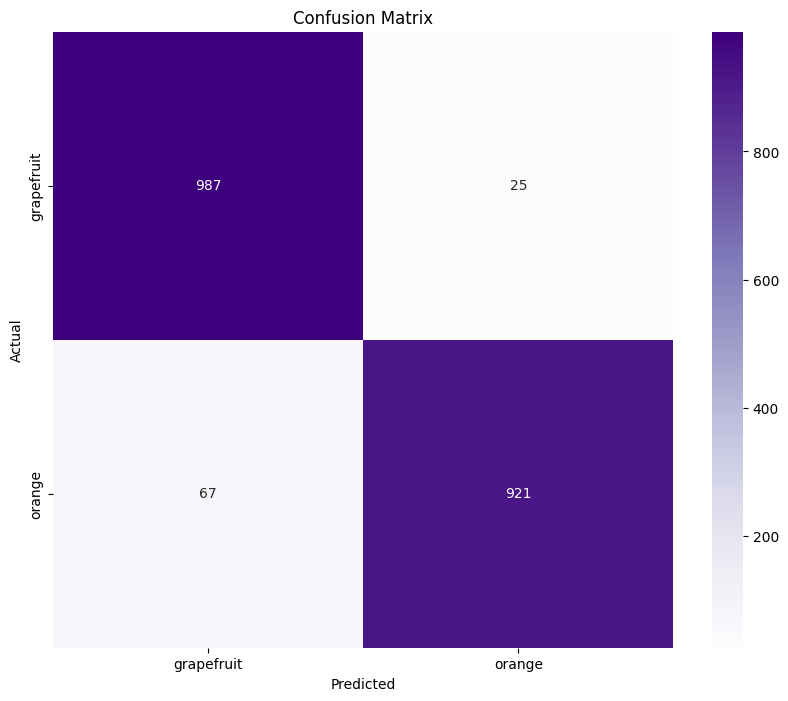

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

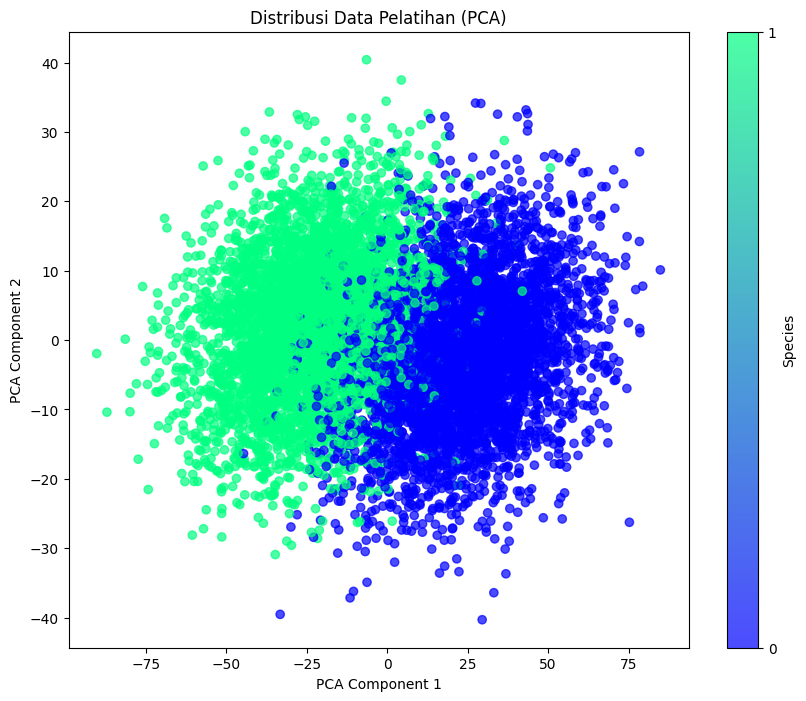

In [14]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap='winter', alpha=0.7)
plt.colorbar(scatter, ticks=range(len(label_encoder.classes_)), label='Species')
plt.title('Distribusi Data Pelatihan (PCA)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

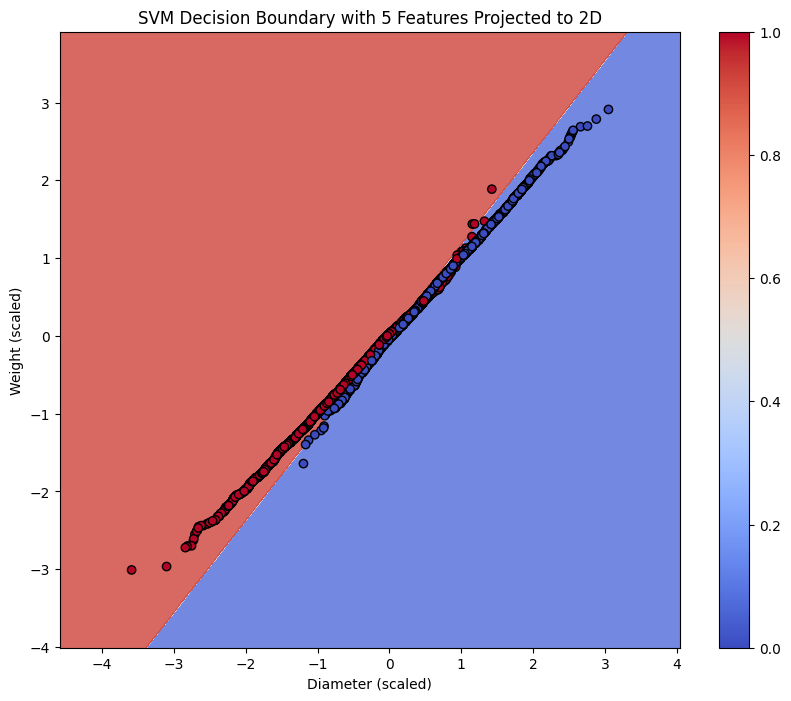

In [19]:
import numpy as np
# Visualisasi dengan hanya dua fitur: 'diameter' dan 'weight'
diameter = 0  # 'diameter'
weight = 1  # 'weight'

# Buat grid untuk dua fitur
x_min, x_max = x_train[:, diameter].min() - 1, x_train[:, diameter].max() + 1
y_min, y_max = x_train[:, weight].min() - 1, x_train[:, weight].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Gabungkan grid dengan nilai rata-rata dari fitur lainnya
Z_input = np.zeros((xx.ravel().shape[0], X.shape[1]))
Z_input[:, diameter] = xx.ravel()  # 'diameter'
Z_input[:, weight] = yy.ravel()  # 'weight'

# Nilai default (rata-rata) untuk fitur lainnya
for i in range(X.shape[1]):
    if i != diameter and i != weight:
        Z_input[:, i] = np.mean(x_train[:, i])

# Prediksi pada grid
Z = classifier.predict(Z_input)
Z = Z.reshape(xx.shape)

# Visualisasi hyperplane
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.8, cmap='coolwarm')
plt.scatter(x_train[:, diameter], x_train[:, weight], c=y_train, edgecolors='k', cmap='coolwarm')
plt.title('SVM Decision Boundary with 5 Features Projected to 2D')
plt.xlabel('Diameter (scaled)')
plt.ylabel('Weight (scaled)')
plt.colorbar()
plt.show()

# Evaluasi model
y_pred = classifier.predict(x_test)

# Saving Model

In [17]:
import joblib
from sklearn.preprocessing import LabelEncoder

# Inisialisasi dan fit label encoder
label_encoder = LabelEncoder()
label_encoder.fit(df_fruit['name'])  

# Menyimpan label_encoder ke dalam file
joblib.dump(label_encoder, 'label_encoder.pkl')
joblib.dump(classifier, 'svm_model.pkl')
joblib.dump(scaler, 'scaler.pkl')



['scaler.pkl']

In [18]:
import joblib

# Memuat model, scaler, dan label_encoder yang telah disimpan
loaded_classifier = joblib.load('svm_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')
label_encoder = joblib.load('label_encoder.pkl')  # Memuat label_encoder yang telah disimpan

# Data input yang akan diprediksi
input_features = [[17.5, 150.11, 299, 91, 92]]  # Diameter, weight, R,G,B

# Melakukan scaling pada input data menggunakan scaler yang telah dimuat
input_scaled = loaded_scaler.transform(input_features)

# Melakukan prediksi dengan model yang dimuat
prediction = loaded_classifier.predict(input_scaled)

# Menampilkan prediksi spesies
print("Prediksi Species:", label_encoder.classes_[prediction][0])


Prediksi Species: grapefruit
